# 비식별화 모델 4종 — 정량 벤치마크

앞선 비교는 "구조 복잡 / 정확도 우수" 같은 **정성 서술**이었습니다. 이 노트북은 같은 4종을
**같은 데이터·같은 조건**으로 돌려 숫자와 그래프를 뽑습니다.

## 왜 논문 수치를 그냥 못 가져다 쓰나

| 모델 | 공개된 수치 | 왜 비교가 안 되나 |
|---|---|---|
| Ultralytics face | WIDERFace 학습·평가 (PR 곡선만 공개) | WIDERFace는 **얼굴만**, 번호판 없음 |
| EgoBlur | 논문 기준 challenging 벤치마크에서 recall 90%+ | **Aria 안경 1인칭 시점** 데이터 기준 |
| dashcam_anonymizer | 없음 | 해외 대시캠 자체 수집 데이터 |
| privacy-blur | 없음 | v8 가중치 재사용 |

학습셋도 테스트셋도 전부 달라서, 이 숫자들을 한 표에 올리면 **틀린 비교**가 됩니다.
쓸 수 있는 숫자는 **내 데이터로 내가 잰 것**뿐입니다.

## 이 노트북이 뽑는 지표

**GT(정답 라벨) 없이 바로 되는 것**
1. **속도** — ms/frame, FPS, 모델 크기, 파라미터 수, VRAM
2. **모델 간 일치도** — IoU 매칭 기반 agreement matrix (어느 모델이 남들과 다르게 보는지)

**GT 50~100프레임을 라벨링하면 되는 것 (핵심)**

3. **Precision / Recall / F1** — 클래스별
4. **PR 곡선 + AP** — conf를 0.01~0.95로 훑어서
5. **객체 크기별 recall** — small / medium / large. 원거리 얼굴을 놓치는지가 여기서 갈립니다
6. **프레임 단위 누락률** — "한 프레임에 하나라도 놓쳤나". 비식별화의 **실제 실패율**
7. **커버리지** — 박스 확대 후 GT 얼굴 면적의 몇 %가 실제로 가려졌나. IoU 0.5로 "맞췄다"고 해도 턱이 튀어나와 있으면 비식별화 실패입니다

> **비식별화는 precision이 아니라 recall 싸움**입니다. 오탐은 배경이 좀 뭉개지는 것뿐이지만,
> 미탐은 개인정보 유출입니다. 6번(프레임 누락률)과 7번(커버리지)이 실제 의사결정 지표입니다.


---
## 0. 설정

In [1]:
from pathlib import Path
import os, sys, time, json, shutil, subprocess, urllib.request
from collections import defaultdict

# ===== 여기만 수정 =====
EVAL_SOURCE = Path(r"C:\Users\Win11Pro\Videos\Captures\포항시 교통정보센터 - Chrome 2026-07-23 11-09-39.mp4")   # 평가용 이미지 폴더 (또는 영상 파일)
GT_DIR      = None   # YOLO 포맷 .txt 라벨 폴더. 없으면 None
WORK_DIR    = Path(r"C:\Users\Win11Pro\Videos")          # 가중치 폴더
OUTPUT_DIR  = Path(r"C:\Users\Win11Pro\Videos")         # 결과 저장

DEVICE   = "0"
IMGSZ    = 1280
N_FRAMES = 100          # 영상 입력일 때 몇 프레임을 샘플링할지
SEED     = 42

# 평가 파라미터
IOU_THR   = 0.5         # 매칭 IoU. 비식별화는 0.3도 실용적 (박스를 확대해서 쓰므로)
BOX_SCALE = 1.20        # 실제 파이프라인과 같은 확대비율. 커버리지 계산에 사용
SCAN_CONF = [round(c, 2) for c in [0.01, 0.03, 0.05, 0.10, 0.15, 0.20, 0.30,
                                   0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95]]
OP_CONF   = 0.10        # P/R/F1 표를 뽑을 운영 임계값

# GT 클래스 인덱스 (YOLO txt의 맨 앞 숫자)
GT_CLASS = {0: "face", 1: "plate"}

# 어떤 모델을 돌릴지
RUN = {"A_ultralytics": True, "B_egoblur": True, "C_dashcam": True, "D_privacyblur": True}
# ======================

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
WORK_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR = WORK_DIR / "models"; MODELS_DIR.mkdir(exist_ok=True)

IMG_EXT = {".png", ".jpg", ".jpeg", ".bmp", ".webp"}
VID_EXT = {".mp4", ".avi", ".mov", ".mkv"}
HAS_GT  = GT_DIR is not None and Path(GT_DIR).exists()

print("평가 소스:", EVAL_SOURCE)
print("GT 라벨   :", GT_DIR if HAS_GT else "(없음 — 속도/일치도만 측정)")
print("출력      :", OUTPUT_DIR)

평가 소스: C:\Users\Win11Pro\Videos\Captures\포항시 교통정보센터 - Chrome 2026-07-23 11-09-39.mp4
GT 라벨   : (없음 — 속도/일치도만 측정)
출력      : C:\Users\Win11Pro\Videos


In [2]:
%pip install -q ultralytics opencv-python gdown pandas matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import cv2, torch, numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt
from ultralytics import YOLO

# Windows 한글 폰트 (없으면 그래프 한글이 □로 깨집니다)
for f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
    try:
        matplotlib.rc("font", family=f); break
    except Exception:
        continue
matplotlib.rcParams["axes.unicode_minus"] = False

if DEVICE != "cpu" and not torch.cuda.is_available():
    print("[warn] CUDA 불가 → cpu 전환"); DEVICE = "cpu"

GPU_NAME = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
print("torch", torch.__version__, "|", GPU_NAME, "| opencv", cv2.__version__)

torch 2.12.0.dev20260408+cu128 | NVIDIA GeForce RTX 5060 Laptop GPU | opencv 4.10.0


---
## 1. 평가 프레임 준비

영상을 넣으면 균등 간격으로 `N_FRAMES`장을 뽑아 이미지로 저장합니다.
**이 저장된 이미지가 곧 라벨링 대상**이 됩니다 — 나중에 GT를 만들 때 그대로 쓰세요.

In [4]:
def imread_u(p):
    img = cv2.imdecode(np.fromfile(str(p), dtype=np.uint8), cv2.IMREAD_COLOR)
    if img is None:
        raise RuntimeError(f"읽기 실패: {p}")
    return img

def imwrite_u(p, img):
    ok, buf = cv2.imencode(Path(p).suffix, img)
    if not ok:
        raise RuntimeError(f"인코딩 실패: {p}")
    buf.tofile(str(p))

FRAME_DIR = OUTPUT_DIR / "frames"; FRAME_DIR.mkdir(exist_ok=True)

if EVAL_SOURCE.is_dir():
    FRAMES = sorted(p for p in EVAL_SOURCE.glob("*") if p.suffix.lower() in IMG_EXT)
    if not FRAMES:
        raise FileNotFoundError(f"이미지가 없습니다: {EVAL_SOURCE}")
elif EVAL_SOURCE.suffix.lower() in VID_EXT:
    cap = cv2.VideoCapture(str(EVAL_SOURCE))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    idxs = np.linspace(0, max(total-1, 0), min(N_FRAMES, max(total, 1)), dtype=int)
    FRAMES = []
    for k, i in enumerate(idxs):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(i))
        ok, f = cap.read()
        if not ok:
            continue
        dst = FRAME_DIR / f"f{k:04d}.png"
        imwrite_u(dst, f); FRAMES.append(dst)
    cap.release()
    print(f"영상에서 {len(FRAMES)}프레임 추출 → {FRAME_DIR}")
else:
    FRAMES = [EVAL_SOURCE]

FRAMES = FRAMES[:N_FRAMES]
h0, w0 = imread_u(FRAMES[0]).shape[:2]
print(f"평가 프레임 {len(FRAMES)}장 · 해상도 {w0}x{h0}")

영상에서 96프레임 추출 → C:\Users\Win11Pro\Videos\frames
평가 프레임 96장 · 해상도 2304x1440


---
## 2. 모델 4종 등록

In [5]:
def download(url, dst, min_mb=0.5):
    if dst.exists() and dst.stat().st_size > min_mb*1e6:
        return dst
    print(f"[get] {dst.name}")
    dst.parent.mkdir(parents=True, exist_ok=True)
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=180) as r, open(dst, "wb") as f:
        shutil.copyfileobj(r, f)
    if dst.stat().st_size < min_mb*1e6:
        dst.unlink(missing_ok=True)
        raise RuntimeError("다운로드 결과가 너무 작음 (URL 사망 가능)")
    return dst

REL = "https://github.com/akanametov/yolo-face/releases/download/1.0.0"
PLATE_URL = ("https://raw.githubusercontent.com/Muhammad-Zeerak-Khan/"
             "Automatic-License-Plate-Recognition-using-YOLOv8/main/license_plate_detector.pt")
PLATE_W = MODELS_DIR / "license_plate_detector.pt"

FACE_KEYS  = ("face", "head")
PLATE_KEYS = ("plate", "lp", "license", "number")

def group_of(name):
    low = str(name).lower()
    if any(k in low for k in PLATE_KEYS): return "plate"
    if any(k in low for k in FACE_KEYS):  return "face"
    return "face"        # 정체불명 클래스는 안전하게 face 취급

def yolo_detector(weight_paths):
    """여러 YOLO 가중치를 묶어 하나의 detect(frame) -> (boxes, scores, groups)로."""
    models = [YOLO(str(p)) for p in weight_paths]
    def detect(frame):
        B, S, G = [], [], []
        for m in models:
            r = m.predict(frame, conf=0.01, imgsz=IMGSZ, device=DEVICE, verbose=False)[0]
            if r.boxes is None or len(r.boxes) == 0:
                continue
            B.append(r.boxes.xyxy.cpu().numpy())
            S.append(r.boxes.conf.cpu().numpy())
            G += [group_of(m.names[int(c)]) for c in r.boxes.cls.cpu().numpy()]
        if not B:
            return np.zeros((0, 4)), np.zeros(0), []
        return np.concatenate(B), np.concatenate(S), G
    meta = dict(size_mb=sum(Path(p).stat().st_size for p in weight_paths)/1e6,
                params_m=sum(sum(x.numel() for x in m.model.parameters()) for m in models)/1e6,
                n_models=len(models),
                weights=", ".join(Path(p).name for p in weight_paths))
    return detect, meta

REGISTRY = {}

In [6]:
# --- A: yolo26n-face + license_plate (개별 탐지, 모델 2개) ---
if RUN["A_ultralytics"]:
    try:
        fw = download(f"{REL}/yolo26n-face.pt", MODELS_DIR / "yolo26n-face.pt")
        pw = download(PLATE_URL, PLATE_W)
        REGISTRY["A_ultralytics"], _m = yolo_detector([fw, pw])
        REGISTRY["A_ultralytics"] = (REGISTRY["A_ultralytics"], _m)
        print("A ok ·", _m["weights"])
    except Exception as e:
        print("A 스킵:", type(e).__name__, e)

# --- B: EgoBlur(.jit 있으면) / 없으면 yolov8l-face 폴백 ---
if RUN["B_egoblur"]:
    try:
        EGO = MODELS_DIR / "egoblur"; EGO.mkdir(exist_ok=True)
        jits = list(EGO.rglob("*.jit"))
        if jits:
            import torchvision
            dev = torch.device("cuda" if DEVICE != "cpu" else "cpu")
            nets = {("plate" if any(k in p.name.lower() for k in ("lp","plate")) else "face"):
                    torch.jit.load(str(p), map_location="cpu").to(dev).eval() for p in jits}
            def _ego(frame):
                t = torch.from_numpy(np.transpose(frame, (2,0,1))).to(dev)
                B, S, G = [], [], []
                for g, m in nets.items():
                    with torch.no_grad():
                        bx, _, sc, _ = m(t.clone())
                    keep = torchvision.ops.nms(bx, sc, 0.3)
                    bx, sc = bx[keep].cpu().numpy(), sc[keep].cpu().numpy()
                    B.append(bx); S.append(sc); G += [g]*len(bx)
                if not B: return np.zeros((0,4)), np.zeros(0), []
                return np.concatenate(B), np.concatenate(S), G
            _m = dict(size_mb=sum(p.stat().st_size for p in jits)/1e6, params_m=float("nan"),
                      n_models=len(nets), weights="EgoBlur .jit")
            REGISTRY["B_egoblur"] = (_ego, _m)
            print("B ok · EgoBlur")
        else:
            fw = download(f"{REL}/yolov8l-face.pt", MODELS_DIR / "yolov8l-face.pt")
            pw = download(PLATE_URL, PLATE_W)
            REGISTRY["B_egoblur"] = yolo_detector([fw, pw])
            print("B ok · 폴백(yolov8l-face) — EgoBlur .jit 없음")
    except Exception as e:
        print("B 스킵:", type(e).__name__, e)

# --- C: dashcam_anonymizer (단일 모델) ---
if RUN["C_dashcam"]:
    try:
        DC = MODELS_DIR / "dashcam_best.pt"
        if not (DC.exists() and DC.stat().st_size > 5e6):
            subprocess.run([sys.executable, "-m", "gdown",
                            "1uV8IMuGDbmDabdjyeSy4SUKV9OS-ULbe", "-O", str(DC)], check=False)
        if not (DC.exists() and DC.stat().st_size > 5e6):
            raise FileNotFoundError("dashcam 가중치 없음 (gdown 할당량? 수동 다운로드 필요)")
        REGISTRY["C_dashcam"] = yolo_detector([DC])
        print("C ok · classes:", YOLO(str(DC)).names)
    except Exception as e:
        print("C 스킵:", type(e).__name__, e)

# --- D: privacy-blur 내부 구성 (yolov8n-face + plate) ---
if RUN["D_privacyblur"]:
    try:
        fw = download(f"{REL}/yolov8n-face.pt", MODELS_DIR / "yolov8n-face.pt")
        pw = download(PLATE_URL, PLATE_W)
        REGISTRY["D_privacyblur"] = yolo_detector([fw, pw])
        print("D ok · yolov8n-face + plate")
    except Exception as e:
        print("D 스킵:", type(e).__name__, e)

print("\n등록된 모델:", list(REGISTRY))
if not REGISTRY:
    raise RuntimeError("사용 가능한 모델이 없습니다.")

[get] yolo26n-face.pt
[get] license_plate_detector.pt
A ok · yolo26n-face.pt, license_plate_detector.pt
[get] yolov8l-face.pt
B ok · 폴백(yolov8l-face) — EgoBlur .jit 없음
C ok · classes: {0: 'license', 1: 'face'}
[get] yolov8n-face.pt
D ok · yolov8n-face + plate

등록된 모델: ['A_ultralytics', 'B_egoblur', 'C_dashcam', 'D_privacyblur']


---
## 3. 추론 1회 + 속도 측정

**conf=0.01로 한 번만 돌려 전부 캐시**합니다. 이후 모든 지표와 PR 곡선은 이 캐시에서 계산되므로
임계값을 바꿔도 재추론이 없습니다.

속도는 워밍업 5장을 버리고 잽니다 (첫 추론은 CUDA 커널 컴파일 때문에 훨씬 느립니다).

In [7]:
CACHE, SPEED = {}, {}
WARMUP = min(5, len(FRAMES))

for name, (detect, meta) in REGISTRY.items():
    print(f"[{name}] 추론 중...")
    imgs = [imread_u(p) for p in FRAMES]

    for i in range(WARMUP):                      # 워밍업 (측정에서 제외)
        detect(imgs[i])
    if DEVICE != "cpu":
        torch.cuda.synchronize(); torch.cuda.reset_peak_memory_stats()

    per_frame, recs = [], []
    for p, img in zip(FRAMES, imgs):
        t = time.perf_counter()
        b, s, g = detect(img)
        if DEVICE != "cpu":
            torch.cuda.synchronize()
        per_frame.append((time.perf_counter()-t)*1000)
        recs.append(dict(frame=p.name, boxes=b, scores=s, groups=g,
                         hw=img.shape[:2]))

    CACHE[name] = recs
    ms = float(np.median(per_frame))
    SPEED[name] = dict(모델=name, **{
        "ms/frame(중앙값)": round(ms, 1),
        "FPS": round(1000/ms, 1),
        "ms(p95)": round(float(np.percentile(per_frame, 95)), 1),
        "가중치MB": round(meta["size_mb"], 1),
        "파라미터M": round(meta["params_m"], 1) if meta["params_m"] == meta["params_m"] else None,
        "모델수": meta["n_models"],
        "VRAM_MB": round(torch.cuda.max_memory_allocated()/1e6, 0) if DEVICE != "cpu" else None,
    })
    print(f"    {ms:.1f} ms/frame · {1000/ms:.1f} FPS · 총 검출 {sum(len(r['boxes']) for r in recs)}")
    del imgs

speed_df = pd.DataFrame(SPEED).T.reset_index(drop=True)
display(speed_df)

[A_ultralytics] 추론 중...
    77.9 ms/frame · 12.8 FPS · 총 검출 1853
[B_egoblur] 추론 중...
    104.8 ms/frame · 9.5 FPS · 총 검출 1735
[C_dashcam] 추론 중...
    67.4 ms/frame · 14.8 FPS · 총 검출 577
[D_privacyblur] 추론 중...
    80.0 ms/frame · 12.5 FPS · 총 검출 1853


,모델,ms/frame(중앙값),FPS,ms(p95),가중치MB,파라미터M,모델수,VRAM_MB
0,A_ultralytics,77.9,12.8,109.2,12.2,5.8,2,118.0
1,B_egoblur,104.8,9.5,119.6,93.9,46.6,2,489.0
2,C_dashcam,67.4,14.8,78.3,87.7,43.6,1,665.0
3,D_privacyblur,80.0,12.5,100.2,12.6,6.1,2,501.0


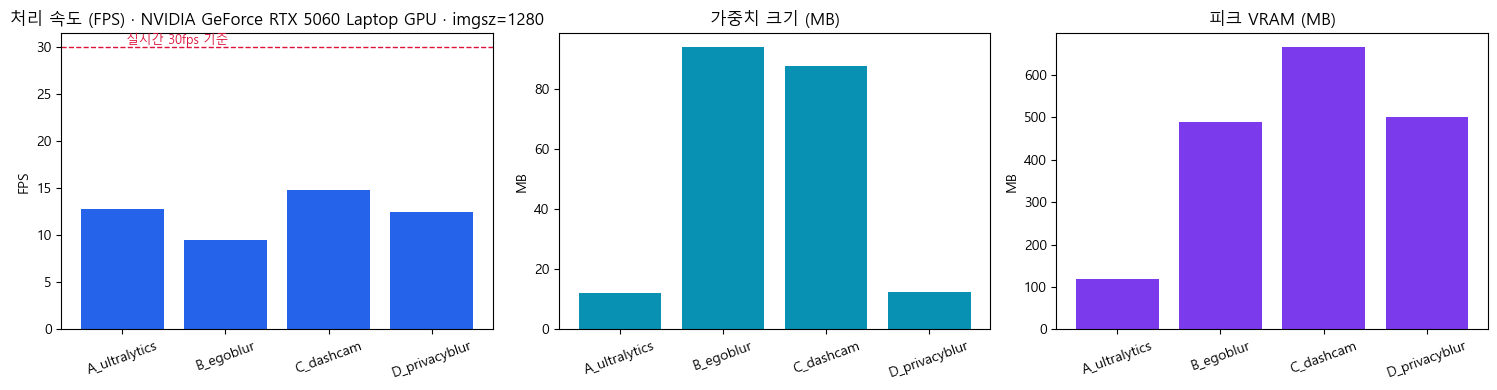

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
names = list(SPEED)

axes[0].bar(names, [SPEED[n]["FPS"] for n in names], color="#2563eb")
axes[0].set_title(f"처리 속도 (FPS) · {GPU_NAME} · imgsz={IMGSZ}"); axes[0].set_ylabel("FPS")
axes[0].axhline(30, ls="--", c="crimson", lw=1)
axes[0].text(0, 30, " 실시간 30fps 기준", c="crimson", va="bottom", fontsize=9)

axes[1].bar(names, [SPEED[n]["가중치MB"] for n in names], color="#0891b2")
axes[1].set_title("가중치 크기 (MB)"); axes[1].set_ylabel("MB")

vram = [SPEED[n]["VRAM_MB"] or 0 for n in names]
axes[2].bar(names, vram, color="#7c3aed")
axes[2].set_title("피크 VRAM (MB)"); axes[2].set_ylabel("MB")

for ax in axes:
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "fig1_speed.png", dpi=150); plt.show()

---
## 4. GT 없이 — 모델 간 일치도

정답이 없어도 **"이 모델만 유독 다르게 본다"**는 건 알 수 있습니다.
두 모델의 박스를 IoU로 매칭해 서로 몇 %나 겹치는지 봅니다.

읽는 법: 행 모델이 잡은 것 중 열 모델도 잡은 비율. **행 전체가 낮으면 그 모델이 과탐**,
**열 전체가 낮으면 그 모델이 미탐** 쪽입니다.

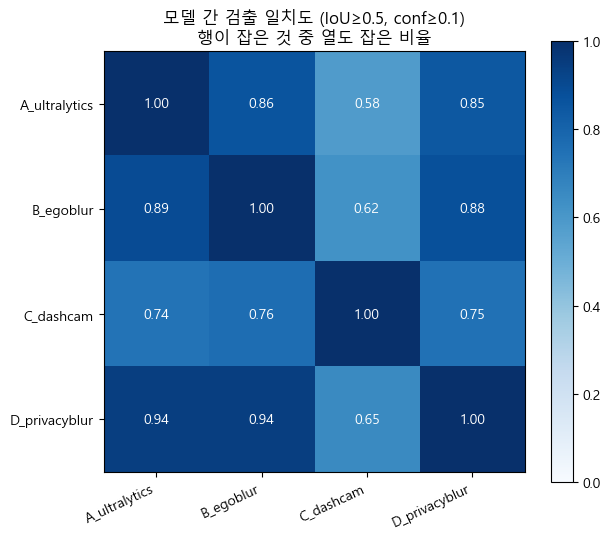


프레임당 검출 수


,A_ultralytics,B_egoblur,C_dashcam,D_privacyblur
mean,2.46,2.4,1.9,2.19
50%,2.50,2.0,2.0,2.00
max,5.00,6.0,4.0,6.00


In [9]:
def iou_matrix(a, b):
    """a:(N,4) b:(M,4) -> (N,M) IoU"""
    if len(a) == 0 or len(b) == 0:
        return np.zeros((len(a), len(b)))
    x1 = np.maximum(a[:, None, 0], b[None, :, 0]); y1 = np.maximum(a[:, None, 1], b[None, :, 1])
    x2 = np.minimum(a[:, None, 2], b[None, :, 2]); y2 = np.minimum(a[:, None, 3], b[None, :, 3])
    inter = np.clip(x2-x1, 0, None) * np.clip(y2-y1, 0, None)
    aa = (a[:, 2]-a[:, 0]) * (a[:, 3]-a[:, 1])
    bb = (b[:, 2]-b[:, 0]) * (b[:, 3]-b[:, 1])
    return inter / np.maximum(aa[:, None] + bb[None, :] - inter, 1e-9)

def boxes_at(name, i, conf):
    r = CACHE[name][i]
    m = r["scores"] >= conf
    return r["boxes"][m], [g for g, k in zip(r["groups"], m) if k]

names = list(CACHE)
agree = np.zeros((len(names), len(names)))
for i, n1 in enumerate(names):
    for j, n2 in enumerate(names):
        hit = tot = 0
        for k in range(len(FRAMES)):
            b1, _ = boxes_at(n1, k, OP_CONF); b2, _ = boxes_at(n2, k, OP_CONF)
            tot += len(b1)
            if len(b1) and len(b2):
                hit += int((iou_matrix(b1, b2).max(axis=1) >= IOU_THR).sum())
        agree[i, j] = hit/tot if tot else np.nan

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(agree, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(names)), names, rotation=25, ha="right")
ax.set_yticks(range(len(names)), names)
for i in range(len(names)):
    for j in range(len(names)):
        v = agree[i, j]
        ax.text(j, i, "-" if v != v else f"{v:.2f}", ha="center", va="center",
                color="white" if v > 0.55 else "black", fontsize=10)
ax.set_title(f"모델 간 검출 일치도 (IoU≥{IOU_THR}, conf≥{OP_CONF})\n행이 잡은 것 중 열도 잡은 비율")
plt.colorbar(im); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig2_agreement.png", dpi=150); plt.show()

cnt = pd.DataFrame({n: [len(boxes_at(n, k, OP_CONF)[0]) for k in range(len(FRAMES))] for n in names})
print("\n프레임당 검출 수")
display(cnt.describe().loc[["mean", "50%", "max"]].round(2))

---
## 5. GT 로드 — 여기부터가 진짜 정확도

`GT_DIR`에 프레임과 같은 이름의 `.txt`(YOLO 포맷: `class cx cy w h`, 0~1 정규화)를 두면
아래 셀부터 전부 계산됩니다. 없으면 자동으로 건너뜁니다.

**GT 만드는 법 (1시간이면 100프레임 충분합니다)** — 6절에 정리해 뒀습니다.

In [10]:
def load_gt(frame_path, hw):
    h, w = hw
    txt = Path(GT_DIR) / (frame_path.stem + ".txt")
    if not txt.exists():
        return np.zeros((0, 4)), []
    B, G = [], []
    for line in txt.read_text(encoding="utf-8").strip().splitlines():
        parts = line.split()
        if len(parts) < 5:
            continue
        c, cx, cy, bw, bh = int(parts[0]), *map(float, parts[1:5])
        B.append([(cx-bw/2)*w, (cy-bh/2)*h, (cx+bw/2)*w, (cy+bh/2)*h])
        G.append(GT_CLASS.get(c, "face"))
    return np.array(B, dtype=float) if B else np.zeros((0, 4)), G

if HAS_GT:
    GT = {}
    for p in FRAMES:
        hw = CACHE[names[0]][FRAMES.index(p)]["hw"]
        GT[p.name] = load_gt(p, hw)
    n_lab = sum(len(v[0]) for v in GT.values())
    n_frm = sum(1 for v in GT.values() if len(v[0]))
    print(f"GT 로드: {n_frm}/{len(FRAMES)} 프레임에 라벨 있음 · 총 객체 {n_lab}개")
    from collections import Counter
    print("클래스 분포:", dict(Counter(g for v in GT.values() for g in v[1])))
    if n_lab == 0:
        print("[warn] 라벨이 0개입니다. 파일명이 프레임과 일치하는지 확인하세요.")
        HAS_GT = False
else:
    print("GT 없음 — 이하 셀은 건너뜁니다. 6절의 라벨링 가이드를 보세요.")

GT 없음 — 이하 셀은 건너뜁니다. 6절의 라벨링 가이드를 보세요.


---
## 6. Precision / Recall / F1 · PR 곡선 · AP

In [11]:
def match(pred, gt, iou_thr=IOU_THR):
    """score 내림차순 greedy 매칭 -> (tp_mask, n_matched_gt)"""
    if len(gt) == 0:
        return np.zeros(len(pred), bool), 0
    if len(pred) == 0:
        return np.zeros(0, bool), 0
    M = iou_matrix(pred, gt)
    used = np.zeros(len(gt), bool)
    tp = np.zeros(len(pred), bool)
    for i in range(len(pred)):
        j = int(np.argmax(np.where(used, -1, M[i])))
        if M[i, j] >= iou_thr and not used[j]:
            tp[i] = True; used[j] = True
    return tp, int(used.sum())

def evaluate(name, conf, group=None, iou_thr=IOU_THR):
    TP = FP = FN = 0
    miss_frames = 0
    for k, p in enumerate(FRAMES):
        gb, gg = GT[p.name]
        pb, pg = boxes_at(name, k, conf)
        sc = CACHE[name][k]["scores"]; sc = sc[sc >= conf]
        if group:
            gm = np.array([g == group for g in gg], bool)
            gb = gb[gm] if len(gb) else gb
            pm = np.array([g == group for g in pg], bool)
            pb = pb[pm] if len(pb) else pb
            sc = sc[pm] if len(sc) == len(pm) else sc
        if len(pb):
            order = np.argsort(-sc[:len(pb)]); pb = pb[order]
        tp, matched = match(pb, gb, iou_thr)
        TP += int(tp.sum()); FP += int((~tp).sum()); FN += len(gb) - matched
        if len(gb) and matched < len(gb):
            miss_frames += 1
    prec = TP/(TP+FP) if TP+FP else 0.0
    rec  = TP/(TP+FN) if TP+FN else 0.0
    f1   = 2*prec*rec/(prec+rec) if prec+rec else 0.0
    n_gt_frames = sum(1 for p in FRAMES if len(GT[p.name][0]))
    return dict(TP=TP, FP=FP, FN=FN, precision=prec, recall=rec, f1=f1,
                프레임누락률=miss_frames/n_gt_frames if n_gt_frames else 0.0)

if HAS_GT:
    rows = []
    for n in names:
        for grp in [None, "face", "plate"]:
            r = evaluate(n, OP_CONF, grp)
            rows.append(dict(모델=n, 대상=grp or "전체",
                             Precision=round(r["precision"], 3), Recall=round(r["recall"], 3),
                             F1=round(r["f1"], 3), TP=r["TP"], FP=r["FP"], FN=r["FN"],
                             프레임누락률=round(r["프레임누락률"], 3)))
    prf = pd.DataFrame(rows)
    display(prf)
    prf.to_csv(OUTPUT_DIR / "metrics_prf.csv", index=False, encoding="utf-8-sig")

In [12]:
if HAS_GT:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    sub = prf[prf["대상"] == "전체"].set_index("모델")

    x = np.arange(len(sub)); w = 0.26
    for i, (col, c) in enumerate([("Precision", "#94a3b8"), ("Recall", "#2563eb"), ("F1", "#0f766e")]):
        axes[0].bar(x + (i-1)*w, sub[col], w, label=col, color=c)
    axes[0].set_xticks(x, sub.index, rotation=20, ha="right"); axes[0].set_ylim(0, 1)
    axes[0].set_title(f"Precision / Recall / F1 (conf={OP_CONF}, IoU≥{IOU_THR})"); axes[0].legend()

    axes[1].bar(sub.index, sub["프레임누락률"], color="#dc2626")
    axes[1].set_title("프레임 단위 누락률 ↓\n(한 프레임에 하나라도 놓친 비율 = 실제 실패율)")
    axes[1].tick_params(axis="x", rotation=20); axes[1].set_ylim(0, 1)

    # PR 곡선 + AP
    for n in names:
        ev = [evaluate(n, c) for c in SCAN_CONF]          # conf 1회씩만 평가
        pts = [(e["recall"], e["precision"]) for e in ev]
        pts = sorted(pts)
        r = np.array([p[0] for p in pts]); pr = np.array([p[1] for p in pts])
        ap = float(np.trapz(pr, r)) if len(r) > 1 else 0.0
        axes[2].plot(r, pr, marker="o", ms=3, label=f"{n} (AP≈{ap:.3f})")
    axes[2].set_xlabel("Recall"); axes[2].set_ylabel("Precision")
    axes[2].set_title(f"PR 곡선 (conf {min(SCAN_CONF)}~{max(SCAN_CONF)} 스윕)")
    axes[2].set_xlim(0, 1); axes[2].set_ylim(0, 1.02); axes[2].legend(fontsize=8); axes[2].grid(alpha=.3)

    plt.tight_layout(); plt.savefig(OUTPUT_DIR / "fig3_accuracy.png", dpi=150); plt.show()

---
## 7. 객체 크기별 recall — 여기서 모델이 갈립니다

COCO 관례로 나눕니다: **small** < 32², **medium** 32²~96², **large** > 96².
CCTV·대시캠은 원거리 얼굴이 대부분 small이라, 전체 recall이 같아도 small recall이 크게 벌어집니다.

In [13]:
if HAS_GT:
    BUCKETS = [("small\n(<32²)", 0, 32*32), ("medium\n(32²~96²)", 32*32, 96*96),
               ("large\n(>96²)", 96*96, np.inf)]

    def recall_by_size(name, conf=OP_CONF):
        hit = defaultdict(int); tot = defaultdict(int)
        for k, p in enumerate(FRAMES):
            gb, _ = GT[p.name]
            if not len(gb):
                continue
            pb, _ = boxes_at(name, k, conf)
            M = iou_matrix(pb, gb)
            matched = (M.max(axis=0) >= IOU_THR) if len(pb) else np.zeros(len(gb), bool)
            area = (gb[:, 2]-gb[:, 0]) * (gb[:, 3]-gb[:, 1])
            for a, ok in zip(area, matched):
                for lab, lo, hi in BUCKETS:
                    if lo <= a < hi:
                        tot[lab] += 1; hit[lab] += int(ok)
        return {lab: (hit[lab]/tot[lab] if tot[lab] else np.nan) for lab, _, _ in BUCKETS}, dict(tot)

    size_rows, counts = [], None
    for n in names:
        r, counts = recall_by_size(n)
        size_rows.append(dict(모델=n, **{k: round(v, 3) if v == v else None for k, v in r.items()}))
    size_df = pd.DataFrame(size_rows)
    print("GT 객체 수:", counts)
    display(size_df)

    fig, ax = plt.subplots(figsize=(8, 4.5))
    labs = [b[0] for b in BUCKETS]; x = np.arange(len(labs)); w = 0.8/len(names)
    for i, row in size_df.iterrows():
        ax.bar(x + (i - (len(names)-1)/2)*w, [row[l] or 0 for l in labs], w, label=row["모델"])
    ax.set_xticks(x, labs); ax.set_ylim(0, 1); ax.set_ylabel("Recall")
    ax.set_title(f"객체 크기별 Recall (conf={OP_CONF}) — 작을수록 어렵습니다")
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=.3)
    plt.tight_layout(); plt.savefig(OUTPUT_DIR / "fig4_recall_by_size.png", dpi=150); plt.show()

---
## 8. 커버리지 — "맞췄다"와 "가려졌다"는 다릅니다

IoU 0.5는 절반만 겹쳐도 통과입니다. 하지만 비식별화에서 얼굴 40%가 노출되면 **실패**입니다.
실제 파이프라인처럼 박스를 `BOX_SCALE`배 확대한 뒤, **GT 얼굴 면적의 몇 %가 실제로 덮였는지**를
픽셀 단위로 잽니다. 이게 최종 판단 지표입니다.

In [14]:
if HAS_GT:
    def expand(b, s=BOX_SCALE):
        x1, y1, x2, y2 = b
        cx, cy = (x1+x2)/2, (y1+y2)/2
        bw, bh = (x2-x1)*s, (y2-y1)*s
        return cx-bw/2, cy-bh/2, cx+bw/2, cy+bh/2

    def coverage(name, conf=OP_CONF):
        covs = []
        for k, p in enumerate(FRAMES):
            gb, _ = GT[p.name]
            if not len(gb):
                continue
            h, w = CACHE[name][k]["hw"]
            pb, _ = boxes_at(name, k, conf)
            mask = np.zeros((h, w), np.uint8)
            for b in pb:
                x1, y1, x2, y2 = [int(round(v)) for v in expand(b)]
                x1, y1 = max(0, x1), max(0, y1); x2, y2 = min(w, x2), min(h, y2)
                if x2 > x1 and y2 > y1:
                    mask[y1:y2, x1:x2] = 1
            for g in gb:
                x1, y1, x2, y2 = [int(round(v)) for v in g]
                x1, y1 = max(0, x1), max(0, y1); x2, y2 = min(w, x2), min(h, y2)
                if x2 > x1 and y2 > y1:
                    covs.append(float(mask[y1:y2, x1:x2].mean()))
        return np.array(covs)

    cov_rows, cov_data = [], {}
    for n in names:
        c = coverage(n); cov_data[n] = c
        cov_rows.append(dict(모델=n, 평균커버리지=round(float(c.mean()), 3) if len(c) else None,
                             완전가림_95이상=round(float((c >= 0.95).mean()), 3) if len(c) else None,
                             부분노출_50미만=round(float((c < 0.5).mean()), 3) if len(c) else None,
                             전혀못가림_0=round(float((c == 0).mean()), 3) if len(c) else None))
    cov_df = pd.DataFrame(cov_rows)
    display(cov_df)
    cov_df.to_csv(OUTPUT_DIR / "metrics_coverage.csv", index=False, encoding="utf-8-sig")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].bar(cov_df["모델"], cov_df["완전가림_95이상"], color="#16a34a")
    axes[0].set_title(f"완전 가림 비율 (커버리지 ≥95%, BOX_SCALE={BOX_SCALE}) ↑")
    axes[0].set_ylim(0, 1); axes[0].tick_params(axis="x", rotation=20)

    for n in names:
        if len(cov_data[n]):
            axes[1].hist(cov_data[n], bins=20, range=(0, 1), histtype="step", lw=2, label=n)
    axes[1].set_xlabel("GT 객체 면적 중 가려진 비율"); axes[1].set_ylabel("객체 수")
    axes[1].set_title("커버리지 분포 — 왼쪽 꼬리가 곧 유출입니다")
    axes[1].legend(fontsize=8)
    plt.tight_layout(); plt.savefig(OUTPUT_DIR / "fig5_coverage.png", dpi=150); plt.show()

---
## 9. 종합 표 + 저장

In [15]:
final = speed_df.copy()
if HAS_GT:
    final = final.merge(prf[prf["대상"] == "전체"].drop(columns=["대상"]), on="모델", how="left")
    final = final.merge(cov_df, on="모델", how="left")
display(final)

final.to_csv(OUTPUT_DIR / "benchmark_summary.csv", index=False, encoding="utf-8-sig")
(OUTPUT_DIR / "benchmark_config.json").write_text(json.dumps(dict(
    gpu=GPU_NAME, imgsz=IMGSZ, iou_thr=IOU_THR, op_conf=OP_CONF, box_scale=BOX_SCALE,
    n_frames=len(FRAMES), has_gt=bool(HAS_GT), source=str(EVAL_SOURCE)
), ensure_ascii=False, indent=2), encoding="utf-8")

print("\n저장 완료:", OUTPUT_DIR)
for f in sorted(OUTPUT_DIR.glob("*.png")) + sorted(OUTPUT_DIR.glob("*.csv")):
    print("  -", f.name)

,모델,ms/frame(중앙값),FPS,ms(p95),가중치MB,파라미터M,모델수,VRAM_MB
0,A_ultralytics,77.9,12.8,109.2,12.2,5.8,2,118.0
1,B_egoblur,104.8,9.5,119.6,93.9,46.6,2,489.0
2,C_dashcam,67.4,14.8,78.3,87.7,43.6,1,665.0
3,D_privacyblur,80.0,12.5,100.2,12.6,6.1,2,501.0



저장 완료: C:\Users\Win11Pro\Videos
  - fig1_speed.png
  - fig2_agreement.png
  - benchmark_summary.csv


---
## 10. GT 라벨 만들기 — 1시간이면 충분합니다

100프레임에 프레임당 3~5개면 300~500박스. 익숙해지면 시간당 400박스는 나옵니다.

| 도구 | 특징 |
|---|---|
| **Label Studio** | `pip install label-studio` → 로컬 웹UI. YOLO 포맷 내보내기 지원 |
| **CVAT** | 영상 라벨링에 강함(보간 기능). Docker 필요 |
| **labelImg** | `pip install labelImg`. 가장 가볍고 YOLO 포맷 기본 |
| **Roboflow** | 웹 기반, 무료 티어. 팀 작업이면 편함 |

**라벨링 규칙** (일관성이 숫자의 신뢰도를 만듭니다)
- 클래스는 `0=face`, `1=plate` 두 개만
- 얼굴은 **이목구비가 보이면 무조건** 박스. 뒤통수·측면 완전 옆모습은 제외하고 기준을 문서에 명시
- 흐릿해서 사람 눈에도 얼굴인지 애매하면 라벨하지 않음 (그래야 recall이 과소평가되지 않습니다)
- 번호판은 판 테두리 기준, 각도가 있어도 외접 사각형

**시간을 줄이는 요령**: 4개 모델의 검출 결과를 합집합(union)으로 미리 그려서 pre-annotation으로
쓰고, 사람은 **틀린 것 지우기 + 놓친 것 추가**만 하세요. 3~4배 빨라집니다.
단 이렇게 만든 GT는 4개 모델이 **전부 놓친 객체**가 빠지므로, 최종 확인은 원본 이미지를
한 번 훑으면서 해야 합니다.

---
## 11. 결과를 어떻게 쓸까

발표·포트폴리오에 넣을 때는 이 순서가 설득력 있습니다.

1. **속도 · 정확도 산점도** — x축 FPS, y축 Recall. 파레토 프런티어 위에 있는 모델이 선택지
2. **프레임 누락률** — "1000프레임 중 N프레임에서 유출" 이라는 문장으로 환산
3. **객체 크기별 recall** — 실패 원인을 구체적으로 짚는 근거
4. **커버리지 분포** — 왜 `BOX_SCALE`을 1.2로 잡았는지의 근거

그리고 조건을 반드시 같이 적으세요: **GPU 모델명, imgsz, conf, IoU 임계값, 프레임 수, 데이터 출처.**
이게 없으면 숫자가 재현 불가능해지고, 면접에서 가장 먼저 지적당하는 부분입니다.

**결론이 예상되는 지점**: C(dashcam)는 모델 1개라 **속도에서 앞서고**, A·B·D는 얼굴 전용 모델을
쓰므로 **작은 얼굴 recall에서 앞설** 가능성이 큽니다. 실제로 그렇게 나오는지, 그 격차가
실시간 요구사항을 포기할 만큼인지가 이 벤치마크로 판가름납니다.

**격차가 크면**: C의 `best.pt`를 시작 가중치로 두고 국내 데이터(AI-Hub 차량 + 직접 라벨링한
프레임)로 파인튜닝하면 "속도는 C, 정확도는 A" 를 한 모델에서 가져올 수 있습니다.
그 재학습 전후 비교를 이 노트북으로 그대로 다시 돌리면, 개선을 숫자로 보여주는 그래프가 나옵니다.
